In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Fraudulent_E-Commerce_Transaction_Data.csv")

df.shape

(1472952, 16)

In [2]:
df.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [3]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Date', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'IP Address',
       'Shipping Address', 'Billing Address', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1472952 non-null  str    
 1   Customer ID         1472952 non-null  str    
 2   Transaction Amount  1472952 non-null  float64
 3   Transaction Date    1472952 non-null  str    
 4   Payment Method      1472952 non-null  str    
 5   Product Category    1472952 non-null  str    
 6   Quantity            1472952 non-null  int64  
 7   Customer Age        1472952 non-null  int64  
 8   Customer Location   1472952 non-null  str    
 9   Device Used         1472952 non-null  str    
 10  IP Address          1472952 non-null  str    
 11  Shipping Address    1472952 non-null  str    
 12  Billing Address     1472952 non-null  str    
 13  Is Fraudulent       1472952 non-null  int64  
 14  Account Age Days    1472952 non-null  int64  
 15  Transaction Hour    147295

In [5]:
df["Is Fraudulent"].value_counts()

Is Fraudulent
0    1399114
1      73838
Name: count, dtype: int64

In [6]:
df["Is Fraudulent"].value_counts(normalize=True) * 100

Is Fraudulent
0    94.987074
1     5.012926
Name: proportion, dtype: float64

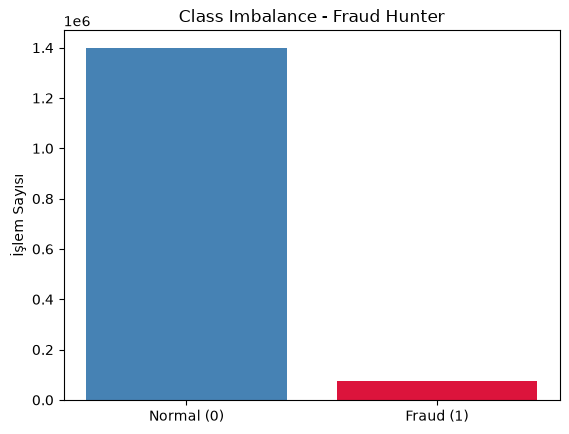

In [7]:
import matplotlib.pyplot as plt

fraud_counts = df["Is Fraudulent"].value_counts()

plt.bar(["Normal (0)", "Fraud (1)"], fraud_counts.values, color=["steelblue", "crimson"])
plt.ylabel("İşlem Sayısı")
plt.title("Class Imbalance - Fraud Hunter")
plt.show()

In [8]:
df[["Transaction Amount", "Customer Age", "Account Age Days", "Quantity", "Transaction Hour"]].describe()

,Transaction Amount,Customer Age,Account Age Days,Quantity,Transaction Hour
count,1.472952e+06,1.472952e+06,1.472952e+06,1.472952e+06,1.472952e+06
mean,2.267683e+02,3.451208e+01,1.796464e+02,3.000230e+00,1.128696e+01
std,2.703951e+02,1.000313e+01,1.068642e+02,1.414736e+00,6.975995e+00
min,1.000000e+01,-1.600000e+01,1.000000e+00,1.000000e+00,0.000000e+00
25%,6.861000e+01,2.800000e+01,8.600000e+01,2.000000e+00,5.000000e+00
50%,1.517600e+02,3.500000e+01,1.790000e+02,3.000000e+00,1.100000e+01
75%,2.960500e+02,4.100000e+01,2.720000e+02,4.000000e+00,1.700000e+01
max,1.270175e+04,8.600000e+01,3.650000e+02,5.000000e+00,2.300000e+01


In [9]:
df[df["Customer Age"] < 0]

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
3193,ed992d5a-4a28-45bf-bdaf-f7e737f5c8f9,4e87ec9a-7bea-4ddf-b0e6-569332c1854b,65.50,2024-02-23 20:38:18,PayPal,home & garden,1,-3,Huntburgh,tablet,99.113.154.217,USNS Brock\nFPO AP 16205,USNS Brock\nFPO AP 16205,0,229,20
7078,1fe82cb8-26a3-464c-908d-415dff80bbe4,7ff030fb-54a5-4764-8b83-108ea2b25651,61.81,2024-01-07 13:48:25,bank transfer,health & beauty,1,-4,Jasminemouth,mobile,199.127.77.116,"4850 Ingram Keys\nEast Amandafurt, WY 22396","518 Craig Parkway Suite 951\nGregoryville, RI ...",0,124,13
8213,a630b0a7-c5ee-4f0f-97f6-4aa3fc2a2d5b,ccabf552-f2ac-43c4-b723-e6bd20de72ca,411.15,2024-02-28 11:42:30,debit card,electronics,4,-4,North Courtney,tablet,37.90.116.230,"4836 Jeremy Shore\nPort Bradleyside, LA 11193","4836 Jeremy Shore\nPort Bradleyside, LA 11193",0,346,11
10110,c5a1ea50-26b3-472d-8729-acc11199bcba,020b3035-d0e9-4a3f-8bd6-a4affe5761f7,241.26,2024-03-03 01:11:29,PayPal,home & garden,3,-1,South Shaneborough,desktop,190.193.198.116,"1828 Manuel Wall Suite 113\nWebbstad, AZ 62193","94016 Hunter Cliff Suite 042\nJimenezfurt, CT ...",0,71,1
13830,6f612d29-c434-4319-bcab-698a076a4122,03121780-f53c-4aa8-ab7d-97a1482518d7,138.22,2024-02-06 19:05:39,credit card,toys & games,2,-1,Holderbury,desktop,7.110.93.93,"7311 Tara Prairie\nSouth Omarmouth, SD 42497","7311 Tara Prairie\nSouth Omarmouth, SD 42497",0,209,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444586,bf42c1ef-da0c-4f92-98e4-c8054afb1e34,c26e0a78-f0cd-404f-9bdf-ad5259238042,860.56,2024-02-29 09:01:17,bank transfer,clothing,2,-9,North Danielle,tablet,124.9.49.190,"2886 Simpson Land Suite 783\nRobinsonburgh, MO...","2886 Simpson Land Suite 783\nRobinsonburgh, MO...",0,68,9
1445037,9332dd89-50cf-4f35-a55d-0524a5f5f475,730ad608-2578-49ec-9cad-91cf3261930d,231.58,2024-01-28 17:44:18,PayPal,electronics,4,-6,Brianside,mobile,157.239.157.148,"0712 Newman Trail Suite 765\nNew Jennachester,...","0712 Newman Trail Suite 765\nNew Jennachester,...",0,252,17
1456987,9aead068-ed3f-444e-9d3d-9de0b6dc68d9,2aa3217b-0a03-440b-a18d-bbf0dadb11c6,30.75,2024-03-26 04:19:39,PayPal,clothing,3,-3,Josephport,tablet,202.246.88.140,"11440 Jesse Via Apt. 329\nVegaview, VI 49897","11440 Jesse Via Apt. 329\nVegaview, VI 49897",0,27,4
1461579,09bdead0-7df1-43ae-8437-5af84a24bdc3,230bf5c8-0516-4295-939e-83f2a4c71d38,129.69,2024-01-30 00:04:35,debit card,electronics,2,-4,New Elizabeth,desktop,205.120.55.253,"679 Megan Dale Suite 663\nNorth Kaitlynville, ...","679 Megan Dale Suite 663\nNorth Kaitlynville, ...",0,152,0


In [10]:
df[df["Customer Age"] < 0]["Is Fraudulent"].value_counts(normalize=True) * 100

Is Fraudulent
0    95.348837
1     4.651163
Name: proportion, dtype: float64

In [11]:
df = df[df["Customer Age"] >= 0]

df.shape

(1472694, 16)

In [12]:
df["Payment Method"].value_counts()

Payment Method
credit card      368361
debit card       368217
bank transfer    368211
PayPal           367905
Name: count, dtype: int64

In [14]:
df["Product Category"].value_counts()

Product Category
health & beauty    295305
electronics        295248
clothing           294257
toys & games       294226
home & garden      293658
Name: count, dtype: int64

In [15]:
df["Device Used"].value_counts()

Device Used
mobile     491663
tablet     490844
desktop    490187
Name: count, dtype: int64

In [16]:
df.groupby("Payment Method")["Is Fraudulent"].mean() * 100

Payment Method
PayPal           5.021405
bank transfer    5.039773
credit card      4.971210
debit card       5.019594
Name: Is Fraudulent, dtype: float64

In [19]:
df.groupby("Product Category")["Is Fraudulent"].mean() * 100

Product Category
clothing           5.032676
electronics        4.952785
health & beauty    5.017863
home & garden      5.014336
toys & games       5.047481
Name: Is Fraudulent, dtype: float64

In [20]:
df.groupby("Device Used")["Is Fraudulent"].mean() * 100

Device Used
desktop    4.986260
mobile     5.056919
tablet     4.995681
Name: Is Fraudulent, dtype: float64

In [21]:
df.groupby("Is Fraudulent")["Customer Age"].mean()

Is Fraudulent
0    34.521298
1    34.468995
Name: Customer Age, dtype: float64

In [22]:
df.groupby("Is Fraudulent")["Account Age Days"].mean()

Is Fraudulent
0    182.988484
1    116.299461
Name: Account Age Days, dtype: float64

In [23]:
df.groupby("Is Fraudulent")["Transaction Hour"].mean()

Is Fraudulent
0    11.467788
1     7.860523
Name: Transaction Hour, dtype: float64

In [26]:
df.groupby("Is Fraudulent")["Transaction Amount"].mean()

Is Fraudulent
0    209.824940
1    547.838719
Name: Transaction Amount, dtype: float64

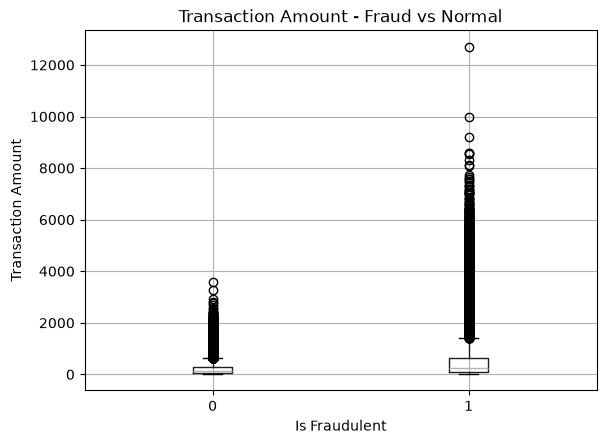

In [27]:
import matplotlib.pyplot as plt

df.boxplot(column="Transaction Amount", by="Is Fraudulent")
plt.title("Transaction Amount - Fraud vs Normal")
plt.suptitle("")
plt.xlabel("Is Fraudulent")
plt.ylabel("Transaction Amount")
plt.show()